# Orlando Housing Fair Market Value Prediction Model (v2)

**Objective:** Build an XGBoost Regressor to predict fair market value (FMV) for Orlando properties.

**Improvements over v1:**
- Baseline model comparisons (Linear Regression, default XGBoost)
- Removed redundant features (raw + log distance pairs)
- Richer feature engineering (spatial clusters, interaction terms, price-per-sqft proxy)
- Early stopping via `eval_set` for free performance
- Optuna for smarter hyperparameter search
- SHAP values for model interpretability
- Permutation importance alongside split-based importance
- Segment-level error analysis by price tier
- Worst-prediction deep dive
- Residual heteroscedasticity discussion
- Cleaned up unused imports

**Pipeline:**
1. Data Loading & Cleaning
2. Exploratory Data Analysis
3. Feature Engineering
4. Baseline Models
5. Hyperparameter Tuning (Optuna + Early Stopping)
6. Cross-Validation Analysis
7. Test Set Evaluation
8. Segment-Level Error Analysis
9. Worst Predictions Deep Dive
10. Feature Importance (Split, Permutation, SHAP)
11. Residual Diagnostics
12. Model Limitations & Discussion
13. Save Model & Prediction Function

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
import shap
import pickle
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading & Cleaning

In [2]:
def load_and_clean_data(filepath):
    """Load data and handle formatting issues."""
    df = pd.read_csv(filepath)
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Columns that need numeric cleaning (have $, commas, spaces)
    currency_cols = ['SALE_PRC', 'LND_SQFOOT', 'TOT_LVG_AREA', 'RAIL_DIST', 'OCEAN_DIST', 'WATER_DIST', 'CNTR_DIST', 'SUBCNTR_DI', 'HWY_DIST']
    
    for col in currency_cols:
        df[col] = (df[col].astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .astype(float))
    
    # Drop ID column - no predictive value
    df = df.drop(columns=['PARCELNO'])
    
    return df

In [3]:
# Load the data
df = load_and_clean_data('../data/orlando-housing-data/orlando-housing-data.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target Range: ${df['SALE_PRC'].min():,.0f} - ${df['SALE_PRC'].max():,.0f}")
print(f"Target Median: ${df['SALE_PRC'].median():,.0f}")
print(f"Target Mean: ${df['SALE_PRC'].mean():,.0f}")
print(f"Target Std: ${df['SALE_PRC'].std():,.0f}")
print(f"Skewness: {df['SALE_PRC'].skew():.2f}")
df.head()

Dataset Shape: 30,000 rows × 16 columns
Target Range: $84,000 - $2,153,000
Target Median: $391,000
Target Mean: $424,752
Target Std: $190,999
Skewness: 1.72


,LATITUDE,LONGITUDE,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,28.38,-81.22,"295,000.00","11,219.00","1,726.66",0,"11,040.20","49,074.23",686.59,"80,000.00","2,659.71","5,493.07",57,0,7,4.50
1,28.75,-81.47,"426,000.00","9,362.00","1,791.49",0,"4,028.65","55,113.18","3,585.26","80,000.00","9,103.72",823.69,9,0,9,3.50
2,28.59,-81.23,"552,000.00","12,200.00","2,970.92",15000,"5,721.78","53,027.05","3,566.58","59,349.62","3,719.80","7,675.31",41,0,11,3.50
3,28.71,-81.45,"219,000.00","5,886.00","1,620.79",0,"8,104.48","46,375.90","1,502.19","67,003.63","31,154.11","1,226.40",12,0,11,3.00
4,28.66,-81.47,"303,000.00","9,763.00","1,249.24",0,"9,163.60","59,228.34","1,807.73","54,212.20","2,068.53","2,315.98",39,0,7,4.50


In [4]:
# Quick data summary
df.describe()

,LATITUDE,LONGITUDE,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
count,"30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00","30,000.00"
mean,28.52,-81.37,"424,752.10","8,918.88","1,968.09","7,067.27","8,027.65","60,024.21","1,508.99","61,697.35","11,987.28","5,016.41",25.97,0.06,6.32,3.86
std,0.12,0.14,"190,998.88","3,498.53",725.31,"12,631.48","7,867.54","14,346.82","1,508.67","18,372.89","11,602.22","4,944.52",16.40,0.23,3.19,0.65
min,28.27,-81.63,"84,000.00","4,502.00",800.00,0.00,200.00,"35,001.36",50.00,233.89,500.00,200.00,1.00,0.00,1.00,2.00
25%,28.42,-81.48,"293,000.00","7,277.00","1,481.38",0.00,"2,340.62","47,723.47",439.32,"53,344.37","3,420.91","1,453.17",11.00,0.00,4.00,3.50
50%,28.52,-81.36,"391,000.00","8,390.00","1,861.25",0.00,"5,572.02","60,011.02","1,041.57","66,087.39","8,366.70","3,498.72",25.00,0.00,6.00,4.00
75%,28.61,-81.24,"514,000.00","9,678.00","2,306.22","10,000.00","11,186.17","72,390.96","2,084.02","78,058.88","16,703.29","6,939.35",38.00,0.00,9.00,4.50
max,28.78,-81.11,"2,153,000.00","44,052.00","6,000.00","50,000.00","50,000.00","84,999.56","15,000.00","80,000.00","60,000.00","30,000.00",62.00,1.00,12.00,5.00


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values:")
print(missing)
print(f"\n→ {'No missing values detected' if missing.sum() == 0 else '⚠️ Missing values found — handle before modeling'}")

Missing Values:
LATITUDE             0
LONGITUDE            0
SALE_PRC             0
LND_SQFOOT           0
TOT_LVG_AREA         0
SPEC_FEAT_VAL        0
RAIL_DIST            0
OCEAN_DIST           0
WATER_DIST           0
CNTR_DIST            0
SUBCNTR_DI           0
HWY_DIST             0
age                  0
avno60plus           0
month_sold           0
structure_quality    0
dtype: int64

→ No missing values detected


## 2. Exploratory Data Analysis

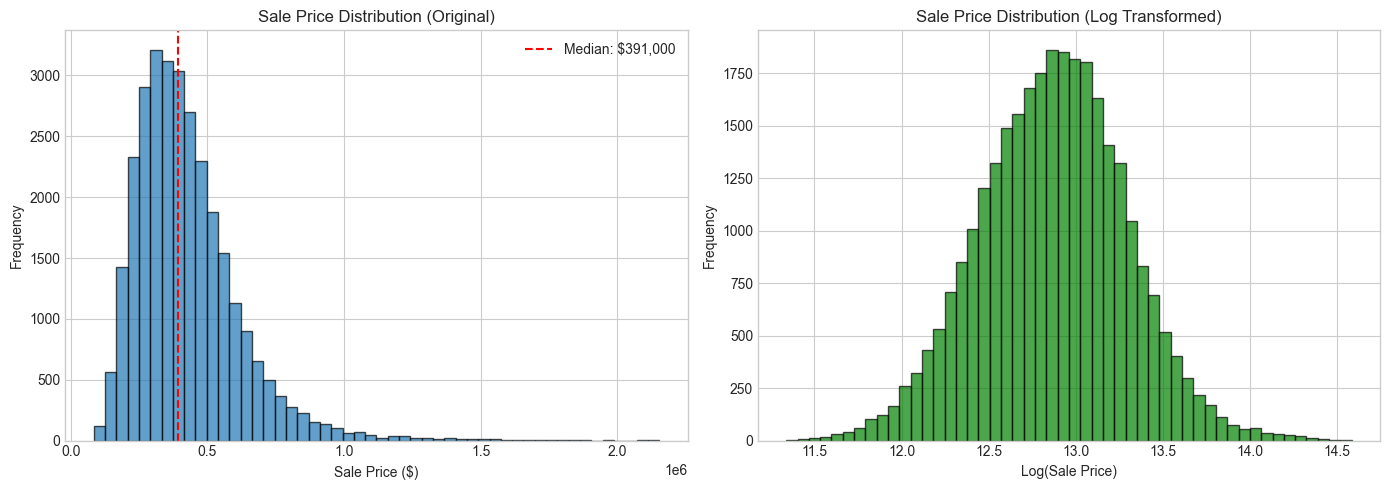

→ Skewness: 1.72 (original) → 0.02 (log)
→ Log transform normalizes the right-skewed distribution


In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
axes[0].hist(df['SALE_PRC'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sale Price Distribution (Original)')
axes[0].axvline(df['SALE_PRC'].median(), color='red', linestyle='--', label=f'Median: ${df["SALE_PRC"].median():,.0f}')
axes[0].legend()

# Log scale
axes[1].hist(np.log1p(df['SALE_PRC']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Sale Price Distribution (Log Transformed)')

plt.tight_layout()
plt.show()

print(f"→ Skewness: {df['SALE_PRC'].skew():.2f} (original) → {np.log1p(df['SALE_PRC']).skew():.2f} (log)")
print("→ Log transform normalizes the right-skewed distribution")

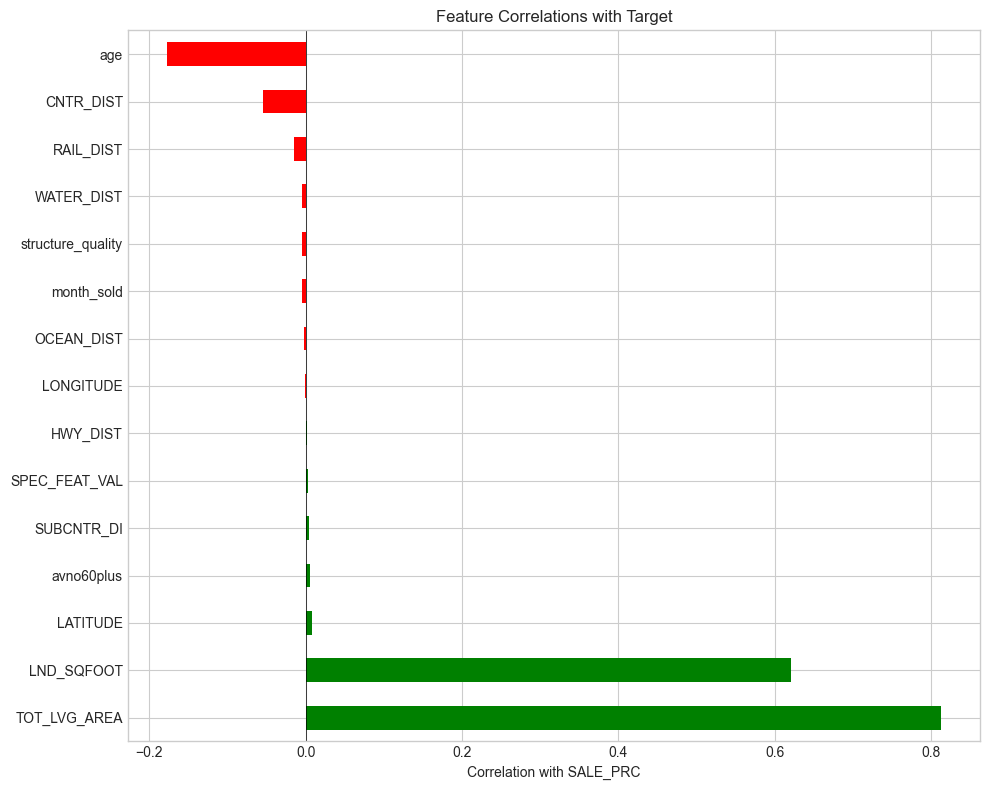


Key observations:
  TOT_LVG_AREA dominates at r=0.813
  LND_SQFOOT second at r=0.621
  Most distance features have weak correlations (|r| < 0.1)


In [7]:
# Correlation with target
correlations = df.corr(numeric_only=True)['SALE_PRC'].drop('SALE_PRC').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in correlations]
correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation with SALE_PRC')
plt.title('Feature Correlations with Target')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  TOT_LVG_AREA dominates at r={correlations['TOT_LVG_AREA']:.3f}")
print(f"  LND_SQFOOT second at r={correlations['LND_SQFOOT']:.3f}")
print(f"  Most distance features have weak correlations (|r| < 0.1)")

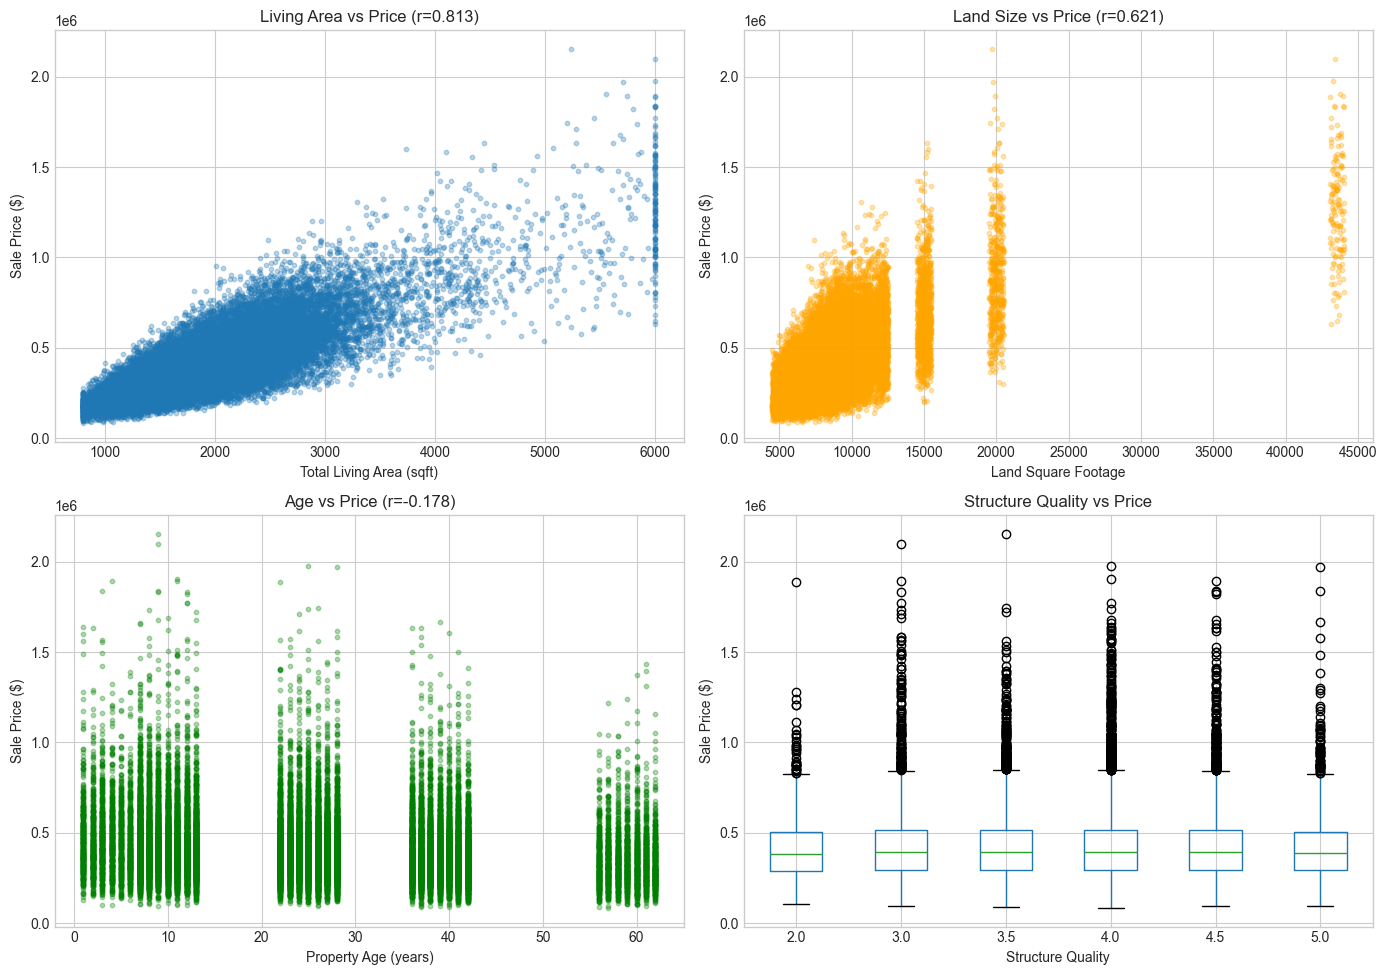

In [8]:
# Key feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Living Area vs Price
axes[0, 0].scatter(df['TOT_LVG_AREA'], df['SALE_PRC'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Total Living Area (sqft)')
axes[0, 0].set_ylabel('Sale Price ($)')
axes[0, 0].set_title(f'Living Area vs Price (r={df["TOT_LVG_AREA"].corr(df["SALE_PRC"]):.3f})')

# Land SqFoot vs Price
axes[0, 1].scatter(df['LND_SQFOOT'], df['SALE_PRC'], alpha=0.3, s=10, color='orange')
axes[0, 1].set_xlabel('Land Square Footage')
axes[0, 1].set_ylabel('Sale Price ($)')
axes[0, 1].set_title(f'Land Size vs Price (r={df["LND_SQFOOT"].corr(df["SALE_PRC"]):.3f})')

# Age vs Price
axes[1, 0].scatter(df['age'], df['SALE_PRC'], alpha=0.3, s=10, color='green')
axes[1, 0].set_xlabel('Property Age (years)')
axes[1, 0].set_ylabel('Sale Price ($)')
axes[1, 0].set_title(f'Age vs Price (r={df["age"].corr(df["SALE_PRC"]):.3f})')

# Structure Quality vs Price
df.boxplot(column='SALE_PRC', by='structure_quality', ax=axes[1, 1])
axes[1, 1].set_xlabel('Structure Quality')
axes[1, 1].set_ylabel('Sale Price ($)')
axes[1, 1].set_title('Structure Quality vs Price')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

**Changes from v1:**
- Dropped raw distance columns (kept only log-transformed versions to eliminate redundancy)
- Added spatial clusters via KMeans on lat/lon (captures neighborhood effects)
- Added quality × area interaction (premium finish on large homes compounds value)
- Added price-per-sqft proxy (land value density)

✓ Fitted 15 spatial clusters on lat/lon


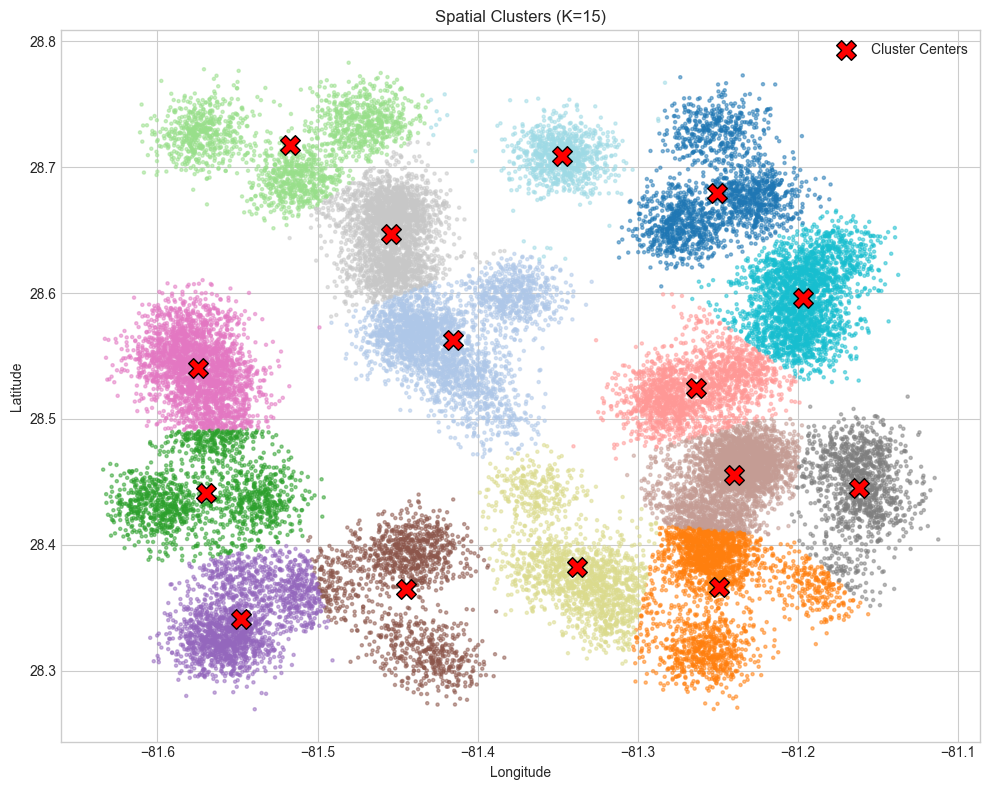

In [9]:
# Fit spatial clusters on FULL dataset before train/test split
# This is safe because it only uses lat/lon (not the target)

N_CLUSTERS = 15
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(df[['LATITUDE', 'LONGITUDE']])
print(f"✓ Fitted {N_CLUSTERS} spatial clusters on lat/lon")

# Visualize clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=kmeans.labels_, cmap='tab20', s=5, alpha=0.5)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 0], c='red', marker='X', s=200, edgecolors='black', linewidths=1, label='Cluster Centers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Spatial Clusters (K={N_CLUSTERS})')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def engineer_features(df, kmeans_model=None):
    """
    Create derived features to improve model performance.
    
    v2 changes:
    - Removed raw distance columns (keep only log-transformed)
    - Added spatial clusters, quality×area interaction, land value density
    """
    df = df.copy()

    
    
    # --- Ratio Features ---
    df['lot_utilization'] = df['TOT_LVG_AREA'] / df['LND_SQFOOT'].clip(lower=1)
    df['area_per_age'] = df['TOT_LVG_AREA'] / (df['age'] + 1)
    df['spec_feat_ratio'] = df['SPEC_FEAT_VAL'] / (df['TOT_LVG_AREA'] * 200).clip(lower=1)
    
    # Land value density: proxy for neighborhood desirability
    df['land_value_density'] = df['LND_SQFOOT'] / (df['CNTR_DIST'] + 1)
    


    # --- Interaction Features ---
    # Quality × Area: premium finishes on large homes compound value
    df['quality_x_area'] = df['structure_quality'] * df['TOT_LVG_AREA']
    
    # Quality × Age: newer high-quality homes command disproportionate premiums
    df['quality_x_age'] = df['structure_quality'] / (df['age'] + 1)
    


    # --- Distance Features (LOG ONLY — no raw) ---
    distance_cols = ['RAIL_DIST', 'OCEAN_DIST', 'WATER_DIST', 'CNTR_DIST', 'SUBCNTR_DI', 'HWY_DIST']
    for col in distance_cols:
        df[f'{col}_log'] = np.log1p(df[col])
    
    # Drop raw distance columns to eliminate redundancy
    df = df.drop(columns=distance_cols)
    
    # Combined urban accessibility score
    df['urban_access'] = 1 / (df['CNTR_DIST_log'] + df['SUBCNTR_DI_log'])
    
    # Water proximity premium indicator
    df['near_water'] = (df['WATER_DIST_log'] < np.log1p(1000)).astype(int)
    
    # Highway convenience (close but not too close, using log thresholds)
    df['hwy_convenience'] = np.where((df['HWY_DIST_log'] > np.log1p(500)) & (df['HWY_DIST_log'] < np.log1p(5000)), 1, 0)
    


    # --- Cyclical Encoding for Month ---
    df['month_sin'] = np.sin(2 * np.pi * df['month_sold'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_sold'] / 12)
    


    # --- Location Features ---
    lat_center = 28.5383  # Downtown Orlando
    lon_center = -81.3792
    df['dist_from_center'] = np.sqrt((df['LATITUDE'] - lat_center)**2 + (df['LONGITUDE'] - lon_center)**2)
    


    # Spatial clusters (captures neighborhood effects)
    if kmeans_model is not None:
        df['spatial_cluster'] = kmeans_model.predict(df[['LATITUDE', 'LONGITUDE']])
    


    # --- Binary Features ---
    df['has_spec_feat'] = (df['SPEC_FEAT_VAL'] > 0).astype(int)
    


    # --- Non-linear Quality ---
    df['quality_sq'] = df['structure_quality'] ** 2
    


    return df

In [11]:
# Apply feature engineering
df_engineered = engineer_features(df, kmeans_model=kmeans)

print(f"Original features: {len(df.columns)}")
print(f"After engineering: {len(df_engineered.columns)}")
print(f"\nFinal feature columns ({len(df_engineered.columns) - 1} features + target):")
print([col for col in df_engineered.columns if col != 'SALE_PRC'])

Original features: 16
After engineering: 31

Final feature columns (30 features + target):
['LATITUDE', 'LONGITUDE', 'LND_SQFOOT', 'TOT_LVG_AREA', 'SPEC_FEAT_VAL', 'age', 'avno60plus', 'month_sold', 'structure_quality', 'lot_utilization', 'area_per_age', 'spec_feat_ratio', 'land_value_density', 'quality_x_area', 'quality_x_age', 'RAIL_DIST_log', 'OCEAN_DIST_log', 'WATER_DIST_log', 'CNTR_DIST_log', 'SUBCNTR_DI_log', 'HWY_DIST_log', 'urban_access', 'near_water', 'hwy_convenience', 'month_sin', 'month_cos', 'dist_from_center', 'spatial_cluster', 'has_spec_feat', 'quality_sq']


## 4. Prepare Data & Baseline Models

Before reaching for XGBoost, we establish baselines to quantify how much value the model complexity adds.

In [12]:
# Separate features and target
X = df_engineered.drop(columns=['SALE_PRC'])
y = np.log1p(df_engineered['SALE_PRC'])  # Log transform target

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature list ({len(X.columns)} features):")
print(X.columns.tolist())

Features shape: (30000, 30)
Target shape: (30000,)

Feature list (30 features):
['LATITUDE', 'LONGITUDE', 'LND_SQFOOT', 'TOT_LVG_AREA', 'SPEC_FEAT_VAL', 'age', 'avno60plus', 'month_sold', 'structure_quality', 'lot_utilization', 'area_per_age', 'spec_feat_ratio', 'land_value_density', 'quality_x_area', 'quality_x_age', 'RAIL_DIST_log', 'OCEAN_DIST_log', 'WATER_DIST_log', 'CNTR_DIST_log', 'SUBCNTR_DI_log', 'HWY_DIST_log', 'urban_access', 'near_water', 'hwy_convenience', 'month_sin', 'month_cos', 'dist_from_center', 'spatial_cluster', 'has_spec_feat', 'quality_sq']


In [13]:
# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set:     {len(X_test):,} samples")

Training set: 24,000 samples
Test set:     6,000 samples


In [14]:
def evaluate_model(y_true_log, y_pred_log, label=""):
    """Evaluate model on original dollar scale. Returns dict of metrics."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    errors = np.abs(y_true - y_pred)
    pct_errors = np.abs((y_true - y_pred) / y_true) * 100
    within_10pct = (pct_errors <= 10).mean() * 100
    within_15pct = (pct_errors <= 15).mean() * 100
    
    metrics = {
        'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape,
        'within_10pct': within_10pct, 'within_15pct': within_15pct
    }
    
    if label:
        print(f"\n{'='*60}")
        print(f"{label}")
        print(f"{'='*60}")
        print(f"RMSE:  ${rmse:,.0f}")
        print(f"MAE:   ${mae:,.0f}")
        print(f"R²:    {r2:.4f}")
        print(f"MAPE:  {mape:.2f}%")
        print(f"Within 10%: {within_10pct:.1f}%")
        print(f"Within 15%: {within_15pct:.1f}%")
    
    return metrics

In [15]:
# ---- BASELINE 1: Median Prediction (naive) ----
y_pred_median = np.full_like(y_test, y_train.median())
baseline_median = evaluate_model(y_test, y_pred_median, "BASELINE 1: Median Prediction")

# ---- BASELINE 2: Linear Regression (raw features) ----
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
baseline_lr = evaluate_model(y_test, y_pred_lr, "BASELINE 2: Linear Regression")

# ---- BASELINE 3: XGBoost with defaults (no tuning) ----
xgb_default = xgb.XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_default.fit(X_train, y_train)
y_pred_default = xgb_default.predict(X_test)
baseline_xgb = evaluate_model(y_test, y_pred_default, "BASELINE 3: XGBoost (defaults, engineered features)")


BASELINE 1: Median Prediction
RMSE:  $197,599
MAE:   $138,801
R²:    -0.0296
MAPE:  35.72%
Within 10%: 18.4%
Within 15%: 27.6%

BASELINE 2: Linear Regression
RMSE:  $120,195
MAE:   $84,403
R²:    0.6191
MAPE:  20.83%
Within 10%: 32.0%
Within 15%: 45.8%

BASELINE 3: XGBoost (defaults, engineered features)
RMSE:  $110,102
MAE:   $81,849
R²:    0.6803
MAPE:  20.63%
Within 10%: 32.2%
Within 15%: 45.9%


In [16]:
# Summary table
baseline_summary = pd.DataFrame({
    'Model': ['Median (naive)', 'Linear Regression', 'XGBoost (defaults)'],
    'R²': [baseline_median['r2'], baseline_lr['r2'], baseline_xgb['r2']],
    'RMSE ($)': [baseline_median['rmse'], baseline_lr['rmse'], baseline_xgb['rmse']],
    'MAE ($)': [baseline_median['mae'], baseline_lr['mae'], baseline_xgb['mae']],
    'MAPE (%)': [baseline_median['mape'], baseline_lr['mape'], baseline_xgb['mape']],
    'Within 10%': [baseline_median['within_10pct'], baseline_lr['within_10pct'], baseline_xgb['within_10pct']],
})

print("\n" + "="*80)
print("BASELINE COMPARISON")
print("="*80)
print(baseline_summary.to_string(index=False))
print("\n→ These baselines set the bar. Tuned XGBoost must meaningfully beat default XGBoost to justify complexity.")


BASELINE COMPARISON
             Model    R²   RMSE ($)    MAE ($)  MAPE (%)  Within 10%
    Median (naive) -0.03 197,599.26 138,801.00     35.72       18.43
 Linear Regression  0.62 120,195.17  84,402.87     20.83       32.00
XGBoost (defaults)  0.68 110,102.43  81,849.11     20.63       32.17

→ These baselines set the bar. Tuned XGBoost must meaningfully beat default XGBoost to justify complexity.


## 5. Hyperparameter Tuning (Optuna + Early Stopping)

**Changes from v1:**
- Optuna instead of GridSearchCV (Bayesian optimization, more efficient for large search spaces)
- Early stopping via `eval_set` to prevent overfitting and find optimal `n_estimators` automatically
- Staged search: tree structure -> boosting params -> regularization

In [17]:
# Hold out a validation set from training data for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=RANDOM_STATE)

print(f"Tuning split: {len(X_tr):,} train / {len(X_val):,} validation / {len(X_test):,} test")

Tuning split: 20,400 train / 3,600 validation / 6,000 test


In [18]:
def optuna_objective(trial):
    """Optuna objective function with early stopping."""
    params = {
        'objective': 'reg:squarederror',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': 0,

        # Tree structure
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),

        # Boosting
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': 2000,  # High ceiling, early stopping will find the right number
        
        # Regularization
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),

        'early_stopping_rounds': 50 # Stop if validation loss doesn't improve for 50 epochs
    }
    
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    return rmse

print("Starting Optuna hyperparameter search (100 trials)...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(optuna_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest trial RMSE (log scale): {study.best_value:.4f}")
print(f"Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-02-14 12:35:58,772] A new study created in memory with name: no-name-f74ad969-d7a5-4c8a-92e6-318918744043


Starting Optuna hyperparameter search (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-14 12:35:58,971] Trial 0 finished with value: 0.24243914679500028 and parameters: {'max_depth': 5, 'min_child_weight': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'gamma': 0.3426417745118369}. Best is trial 0 with value: 0.24243914679500028.
[I 2026-02-14 12:36:00,498] Trial 1 finished with value: 0.24368707350359414 and parameters: {'max_depth': 7, 'min_child_weight': 8, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9162213204002109, 'reg_alpha': 8.148018307012941e-07, 'reg_lambda': 4.329370014459266e-07, 'gamma': 3.939402261362697e-07}. Best is trial 0 with value: 0.24243914679500028.
[I 2026-02-14 12:36:00,771] Trial 2 finished with value: 0.2422533043906515 and parameters: {'max_depth': 5, 'min_child_weight': 6, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167,

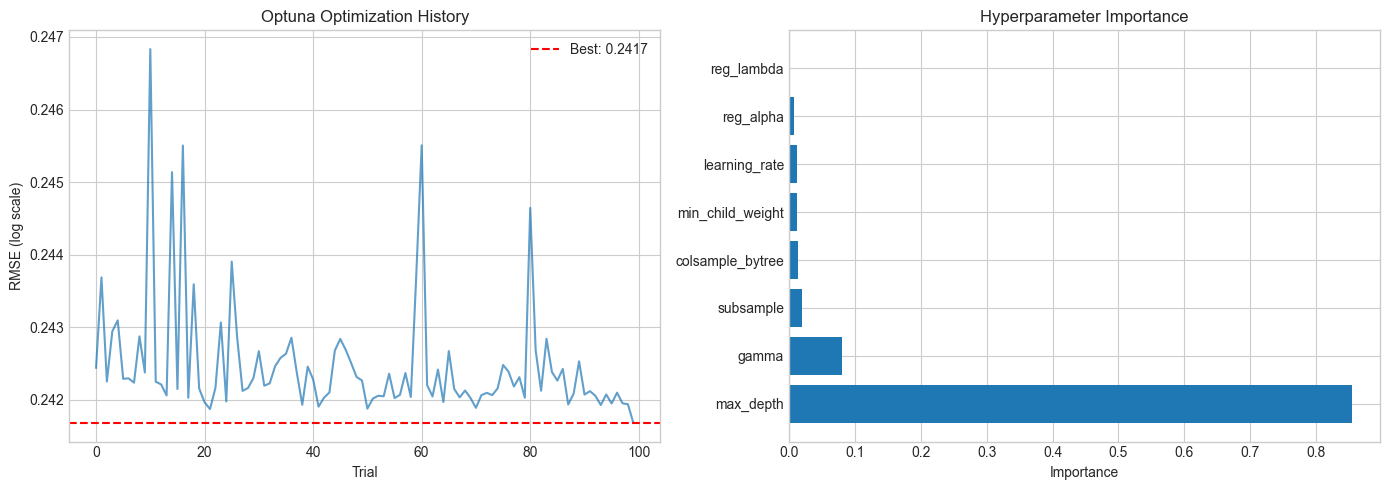

In [19]:
# Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial values
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, alpha=0.7)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_title('Optuna Optimization History')
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].legend()

# Parameter importance
param_importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(param_importance.keys()), list(param_importance.values()))
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.show()

In [20]:
# Train final model on FULL training set with best params + early stopping
best_params = study.best_params.copy()
best_params.update({
    'objective': 'reg:squarederror',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0,
    'n_estimators': 2000,  # Early stopping will select the right number
})

# Use a small validation holdout for early stopping
X_train_final, X_es_val, y_train_final, y_es_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=RANDOM_STATE
)

best_model = xgb.XGBRegressor(**best_params)
best_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_es_val, y_es_val)],
    verbose=False
)

print(f"✓ Final model trained")
print(f"  Best params: {best_params}")

✓ Final model trained
  Best params: {'max_depth': 3, 'min_child_weight': 6, 'learning_rate': 0.10020138699991916, 'subsample': 0.8027749922997636, 'colsample_bytree': 0.9068551435477592, 'reg_alpha': 0.0007176229327904417, 'reg_lambda': 0.003882595975592982, 'gamma': 0.02446589218470084, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0, 'n_estimators': 2000}


## 6. Cross-Validation Analysis

In [21]:
def cross_validation_analysis(params, X, y, cv_folds=5):
    """Detailed cross-validation analysis with multiple metrics."""
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]
        
        # Further split for early stopping within each fold
        X_tr_f, X_es_f, y_tr_f, y_es_f = train_test_split(
            X_train_fold, y_train_fold, test_size=0.1, random_state=RANDOM_STATE
        )
        
        fold_model = xgb.XGBRegressor(**params)
        fold_model.fit(
            X_tr_f, y_tr_f,
            eval_set=[(X_es_f, y_es_f)],
            verbose=False
        )
        
        y_pred_log = fold_model.predict(X_val_fold)
        y_val_orig = np.expm1(y_val_fold)
        y_pred_orig = np.expm1(y_pred_log)
        
        rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
        mae = mean_absolute_error(y_val_orig, y_pred_orig)
        r2 = r2_score(y_val_orig, y_pred_orig)
        mape = np.mean(np.abs((y_val_orig - y_pred_orig) / y_val_orig)) * 100
        
        fold_results.append({'fold': fold, 'rmse': rmse, 'mae': mae, 'r2': r2, 
                             'mape': mape, 'n_trees': fold_model.best_iteration + 1})
    
    return pd.DataFrame(fold_results)

In [22]:
# Run CV analysis
best_params['early_stopping_rounds'] = 50

cv_results = cross_validation_analysis(best_params, X_train, y_train, cv_folds=5)
cv_results

,fold,rmse,mae,r2,mape,n_trees
0,1,"107,260.24","79,372.87",0.68,19.94,65
1,2,"105,595.53","79,206.61",0.69,20.13,43
2,3,"107,926.83","80,790.57",0.70,20.22,73
3,4,"105,256.49","78,369.29",0.69,19.84,100
4,5,"105,689.12","79,578.65",0.68,19.80,69


In [23]:
# CV Summary
print("="*60)
print("CROSS-VALIDATION SUMMARY (5-Fold)")
print("="*60)
print(f"RMSE:    ${cv_results['rmse'].mean():,.0f} ± ${cv_results['rmse'].std():,.0f}")
print(f"MAE:     ${cv_results['mae'].mean():,.0f} ± ${cv_results['mae'].std():,.0f}")
print(f"R²:      {cv_results['r2'].mean():.4f} ± {cv_results['r2'].std():.4f}")
print(f"MAPE:    {cv_results['mape'].mean():.2f}% ± {cv_results['mape'].std():.2f}%")
print(f"Trees:   {cv_results['n_trees'].mean():.0f} ± {cv_results['n_trees'].std():.0f} (via early stopping)")

CROSS-VALIDATION SUMMARY (5-Fold)
RMSE:    $106,346 ± $1,174
MAE:     $79,464 ± $873
R²:      0.6865 ± 0.0093
MAPE:    19.99% ± 0.18%
Trees:   70 ± 20 (via early stopping)


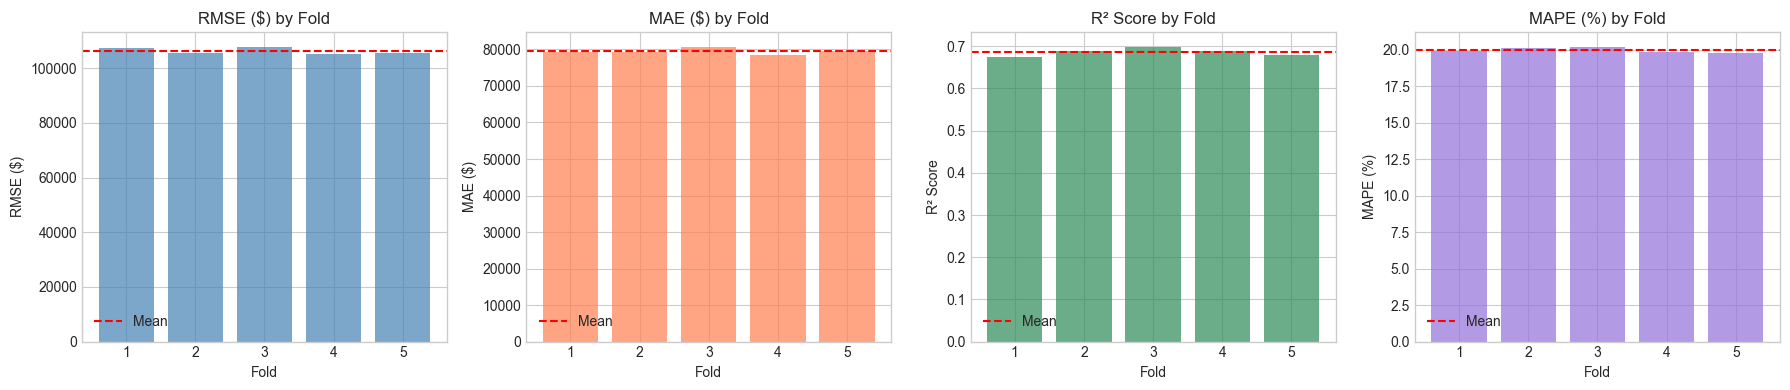


--- Overfitting Check ---
Train R²:  0.7956
CV R²:     0.6865
Gap:       0.1091
⚠️ Possible overfitting (gap > 0.10)


In [24]:
# Visualize CV results
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

metrics = ['rmse', 'mae', 'r2', 'mape']
titles = ['RMSE ($)', 'MAE ($)', 'R² Score', 'MAPE (%)']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(cv_results['fold'], cv_results[metric], color=color, alpha=0.7)
    ax.axhline(cv_results[metric].mean(), color='red', linestyle='--', label='Mean')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Fold')
    ax.legend()

plt.tight_layout()
plt.show()

# Overfitting check
y_train_pred = best_model.predict(X_train)
train_r2 = r2_score(np.expm1(y_train), np.expm1(y_train_pred))
cv_r2 = cv_results['r2'].mean()

print(f"\n--- Overfitting Check ---")
print(f"Train R²:  {train_r2:.4f}")
print(f"CV R²:     {cv_r2:.4f}")
print(f"Gap:       {train_r2 - cv_r2:.4f}")
if train_r2 - cv_r2 > 0.10:
    print("⚠️ Possible overfitting (gap > 0.10)")
else:
    print("✓ Gap is acceptable")

## 7. Test Set Evaluation

In [25]:
# Predictions on test set
y_pred_log = best_model.predict(X_test)

# Convert back to original scale
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

# Full evaluation
test_metrics = evaluate_model(y_test, y_pred_log, "TEST SET EVALUATION (Tuned XGBoost v2)")

# Accuracy buckets
errors = np.abs(y_test_orig - y_pred_orig)
pct_errors = np.abs((y_test_orig - y_pred_orig) / y_test_orig) * 100

print(f"\nPrediction Accuracy Buckets:")
print(f"  Within $25K:   {(errors <= 25000).mean() * 100:.1f}%")
print(f"  Within $50K:   {(errors <= 50000).mean() * 100:.1f}%")
print(f"  Within $100K:  {(errors <= 100000).mean() * 100:.1f}%")
print(f"  Within 5%:     {(pct_errors <= 5).mean() * 100:.1f}%")
print(f"  Within 10%:    {(pct_errors <= 10).mean() * 100:.1f}%")
print(f"  Within 15%:    {(pct_errors <= 15).mean() * 100:.1f}%")
print(f"  Within 20%:    {(pct_errors <= 20).mean() * 100:.1f}%")


TEST SET EVALUATION (Tuned XGBoost v2)
RMSE:  $109,301
MAE:   $81,472
R²:    0.6850
MAPE:  20.59%
Within 10%: 32.0%
Within 15%: 46.3%

Prediction Accuracy Buckets:
  Within $25K:   21.7%
  Within $50K:   41.2%
  Within $100K:  69.7%
  Within 5%:     16.1%
  Within 10%:    32.0%
  Within 15%:    46.3%
  Within 20%:    59.4%


In [26]:
# ---- Compare all models ----
comparison = pd.DataFrame({
    'Model': ['Median (naive)', 'Linear Regression', 'XGBoost (defaults)', 'XGBoost (tuned v2)'],
    'R²': [baseline_median['r2'], baseline_lr['r2'], baseline_xgb['r2'], test_metrics['r2']],
    'RMSE': [baseline_median['rmse'], baseline_lr['rmse'], baseline_xgb['rmse'], test_metrics['rmse']],
    'MAE': [baseline_median['mae'], baseline_lr['mae'], baseline_xgb['mae'], test_metrics['mae']],
    'MAPE': [baseline_median['mape'], baseline_lr['mape'], baseline_xgb['mape'], test_metrics['mape']],
    'Within 10%': [baseline_median['within_10pct'], baseline_lr['within_10pct'], 
    baseline_xgb['within_10pct'], test_metrics['within_10pct']],
})

print("\n" + "="*90)
print("FULL MODEL COMPARISON")
print("="*90)
print(comparison.to_string(index=False))

# Improvement over baselines
print(f"\n--- Improvement over baselines ---")
print(f"vs Linear Regression:    ΔR² = +{test_metrics['r2'] - baseline_lr['r2']:.4f}, ΔMAPE = {test_metrics['mape'] - baseline_lr['mape']:.2f}%")
print(f"vs XGBoost (defaults):   ΔR² = +{test_metrics['r2'] - baseline_xgb['r2']:.4f}, ΔMAPE = {test_metrics['mape'] - baseline_xgb['mape']:.2f}%")


FULL MODEL COMPARISON
             Model    R²       RMSE        MAE  MAPE  Within 10%
    Median (naive) -0.03 197,599.26 138,801.00 35.72       18.43
 Linear Regression  0.62 120,195.17  84,402.87 20.83       32.00
XGBoost (defaults)  0.68 110,102.43  81,849.11 20.63       32.17
XGBoost (tuned v2)  0.68 109,300.87  81,471.64 20.59       32.03

--- Improvement over baselines ---
vs Linear Regression:    ΔR² = +0.0659, ΔMAPE = -0.24%
vs XGBoost (defaults):   ΔR² = +0.0046, ΔMAPE = -0.03%


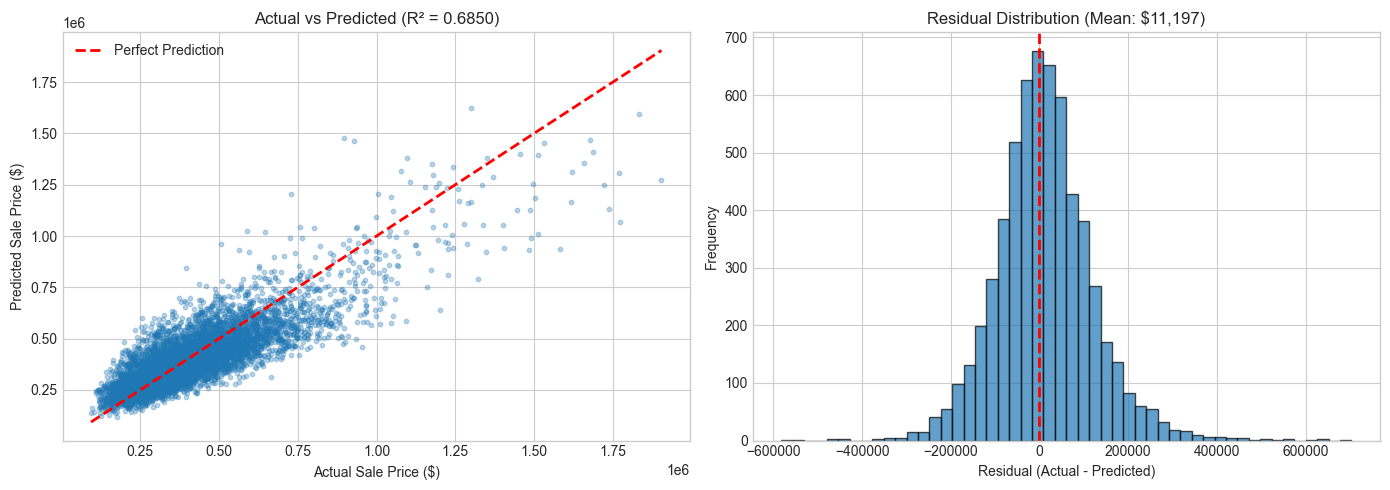

In [27]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.3, s=10)
axes[0].plot([y_test_orig.min(), y_test_orig.max()], 
             [y_test_orig.min(), y_test_orig.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].set_title(f'Actual vs Predicted (R² = {test_metrics["r2"]:.4f})')
axes[0].legend()

# Residual distribution
residuals = y_test_orig - y_pred_orig
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (Mean: ${residuals.mean():,.0f})')

plt.tight_layout()
plt.show()

## 8. Segment-Level Error Analysis

Global metrics can mask poor performance in specific price segments. This section breaks down accuracy by price tier to identify where the model struggles most.

In [28]:
# Performance by price segment
segments = [
    (0, 200000, 'Under $200K'),
    (200000, 300000, '$200K-$300K'),
    (300000, 400000, '$300K-$400K'),
    (400000, 500000, '$400K-$500K'),
    (500000, 700000, '$500K-$700K'),
    (700000, 1000000, '$700K-$1M'),
    (1000000, float('inf'), '$1M+'),
]

segment_results = []
for low, high, label in segments:
    mask = (y_test_orig >= low) & (y_test_orig < high)
    n = mask.sum()
    if n > 0:
        seg_pred = y_pred_orig[mask]
        seg_actual = y_test_orig[mask]
        seg_mape = np.mean(np.abs((seg_actual - seg_pred) / seg_actual)) * 100
        seg_mae = mean_absolute_error(seg_actual, seg_pred)
        seg_r2 = r2_score(seg_actual, seg_pred) if n > 1 else np.nan
        seg_within10 = (np.abs((seg_actual - seg_pred) / seg_actual) * 100 <= 10).mean() * 100
        seg_bias = (seg_pred - seg_actual).mean()  # positive = overpredict
        
        segment_results.append({
            'Segment': label, 'n': n, 'MAPE (%)': seg_mape, 'MAE ($)': seg_mae,
            'R²': seg_r2, 'Within 10%': seg_within10, 'Avg Bias ($)': seg_bias
        })

seg_df = pd.DataFrame(segment_results)

print("="*100)
print("PERFORMANCE BY PRICE SEGMENT")
print("="*100)
print(seg_df.to_string(index=False, float_format='{:.1f}'.format))

PERFORMANCE BY PRICE SEGMENT
    Segment    n  MAPE (%)  MAE ($)    R²  Within 10%  Avg Bias ($)
Under $200K  333      46.6  76106.5 -13.9        11.4       74090.8
$200K-$300K 1332      24.8  62388.3  -7.8        29.9       44384.7
$300K-$400K 1471      17.8  61535.3  -7.0        37.2       14614.0
$400K-$500K 1273      15.4  69258.1  -7.9        38.3      -16473.1
$500K-$700K 1147      17.0  98919.3  -3.7        31.6      -66588.7
  $700K-$1M  349      22.5 182242.4  -5.3        19.8     -156355.8
       $1M+   95      20.5 259348.8  -0.8        21.1     -216369.2


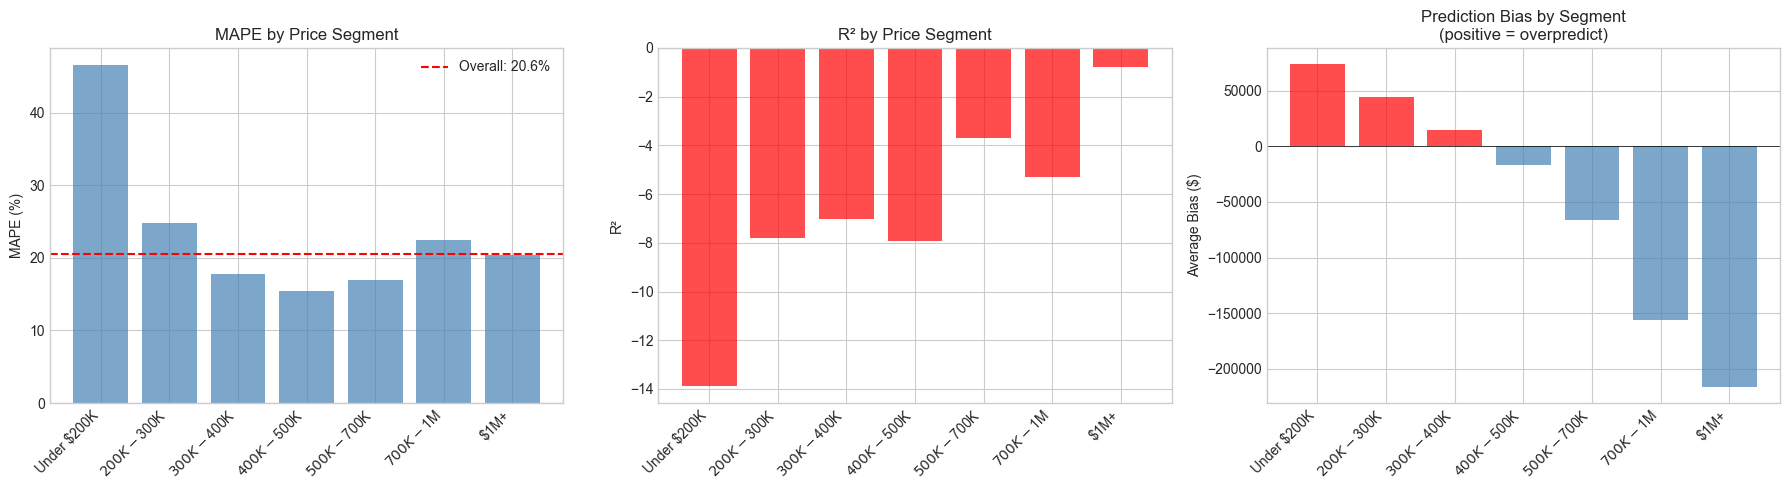


Key findings:
  Worst segment: Under $200K (MAPE=46.6%, n=333)
  Best segment:  $400K-$500K (MAPE=15.4%, n=1273)


In [29]:
# Visualize segment performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = range(len(seg_df))
labels = seg_df['Segment']

# MAPE by segment
bars = axes[0].bar(x, seg_df['MAPE (%)'], color='steelblue', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE by Price Segment')
axes[0].axhline(test_metrics['mape'], color='red', linestyle='--', label=f'Overall: {test_metrics["mape"]:.1f}%')
axes[0].legend()

# R² by segment
colors = ['red' if r < 0 else 'seagreen' for r in seg_df['R²']]
axes[1].bar(x, seg_df['R²'], color=colors, alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('R²')
axes[1].set_title('R² by Price Segment')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)

# Bias by segment
colors_bias = ['red' if b > 0 else 'steelblue' for b in seg_df['Avg Bias ($)']]
axes[2].bar(x, seg_df['Avg Bias ($)'], color=colors_bias, alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right')
axes[2].set_ylabel('Average Bias ($)')
axes[2].set_title('Prediction Bias by Segment\n(positive = overpredict)')
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nKey findings:")
worst = seg_df.loc[seg_df['MAPE (%)'].idxmax()]
best = seg_df.loc[seg_df['MAPE (%)'].idxmin()]
print(f"  Worst segment: {worst['Segment']} (MAPE={worst['MAPE (%)']:.1f}%, n={worst['n']:.0f})")
print(f"  Best segment:  {best['Segment']} (MAPE={best['MAPE (%)']:.1f}%, n={best['n']:.0f})")

## 9. Worst Predictions Deep Dive

Examining the model's worst predictions reveals systematic failure modes and potential data quality issues.

In [30]:
# Worst 5% of predictions
test_analysis = X_test.copy()
test_analysis['actual'] = y_test_orig.values
test_analysis['predicted'] = y_pred_orig
test_analysis['error'] = errors.values
test_analysis['pct_error'] = pct_errors.values
test_analysis['residual'] = residuals.values

# Top 5% worst predictions
threshold = np.percentile(pct_errors, 95)
worst_preds = test_analysis[test_analysis['pct_error'] >= threshold].sort_values('pct_error', ascending=False)

print(f"Worst 5% threshold: {threshold:.1f}% error")
print(f"Number of worst predictions: {len(worst_preds)}")
print(f"\n--- Sample of worst predictions ---")
display_cols = ['actual', 'predicted', 'pct_error', 'residual', 
                'TOT_LVG_AREA', 'LND_SQFOOT', 'age', 'structure_quality', 'spatial_cluster']
print(worst_preds[display_cols].head(15).to_string())

Worst 5% threshold: 57.1% error
Number of worst predictions: 300

--- Sample of worst predictions ---
          actual  predicted  pct_error    residual  TOT_LVG_AREA  LND_SQFOOT  age  structure_quality  spatial_cluster
20624 200,000.00 484,216.78     142.11 -284,216.78      2,172.25    7,254.00   28               3.00                7
2714  164,000.00 395,625.75     141.24 -231,625.75      1,862.12   10,553.00   39               3.00               10
1179  141,000.00 337,261.12     139.19 -196,261.13      1,591.51    7,131.00   60               3.50                8
15518 257,000.00 599,627.56     133.32 -342,627.56      2,712.74   11,830.00   27               4.00                3
1569  234,000.00 543,490.62     132.26 -309,490.63      2,481.90    8,668.00   42               4.00                2
25714 164,000.00 379,057.06     131.13 -215,057.06      1,664.35    9,540.00   60               3.50                1
17311 153,000.00 351,030.06     129.43 -198,030.06      1,332.60    5,58

In [31]:
# Characterize worst predictions vs good predictions
good_mask = pct_errors <= np.percentile(pct_errors, 50)
bad_mask = pct_errors >= threshold

comparison_features = ['TOT_LVG_AREA', 'LND_SQFOOT', 'age', 'structure_quality', 'lot_utilization']

print("\n" + "="*70)
print("WORST 5% vs BEST 50% — Feature Distributions")
print("="*70)
print(f"{'Feature':<25} {'Best 50% (median)':<20} {'Worst 5% (median)':<20}")
print("-"*65)
for feat in comparison_features:
    good_val = X_test.loc[good_mask, feat].median()
    bad_val = X_test.loc[bad_mask, feat].median()
    print(f"{feat:<25} {good_val:<20.1f} {bad_val:<20.1f}")

# Check if worst predictions cluster in specific spatial areas
print(f"\n--- Spatial cluster distribution in worst predictions ---")
worst_clusters = X_test.loc[bad_mask, 'spatial_cluster'].value_counts().head(5)
total_per_cluster = X_test['spatial_cluster'].value_counts()
print(f"{'Cluster':<10} {'Worst 5% count':<18} {'Total in cluster':<18} {'Failure rate':<15}")
for cluster, count in worst_clusters.items():
    total = total_per_cluster[cluster]
    print(f"{cluster:<10} {count:<18} {total:<18} {count/total*100:.1f}%")


WORST 5% vs BEST 50% — Feature Distributions
Feature                   Best 50% (median)    Worst 5% (median)   
-----------------------------------------------------------------
TOT_LVG_AREA              1848.3               1819.3              
LND_SQFOOT                8342.0               8455.5              
age                       25.0                 26.0                
structure_quality         4.0                  4.0                 
lot_utilization           0.2                  0.2                 

--- Spatial cluster distribution in worst predictions ---
Cluster    Worst 5% count     Total in cluster   Failure rate   
13         36                 508                7.1%
8          35                 637                5.5%
1          32                 562                5.7%
9          23                 517                4.4%
2          20                 472                4.2%


## 10. Feature Importance (Split-Based, Permutation, SHAP)

In [32]:
# ---- 10a. Split-based importance (XGBoost native) ----
importance_split = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("="*60)
print("SPLIT-BASED FEATURE IMPORTANCE (XGBoost native)")
print("="*60)
for _, row in importance_split.head(15).iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<25} {row['importance']:.4f} {bar}")

SPLIT-BASED FEATURE IMPORTANCE (XGBoost native)
  TOT_LVG_AREA              0.6491 ████████████████████████████████
  area_per_age              0.0603 ███
  quality_x_area            0.0271 █
  land_value_density        0.0151 
  age                       0.0125 
  hwy_convenience           0.0121 
  dist_from_center          0.0115 
  CNTR_DIST_log             0.0113 
  LND_SQFOOT                0.0109 
  month_cos                 0.0106 
  month_sin                 0.0103 
  lot_utilization           0.0102 
  month_sold                0.0101 
  spatial_cluster           0.0101 
  quality_x_age             0.0098 


In [33]:
# ---- 10b. Permutation importance (model-agnostic, more reliable) ----
print("Computing permutation importance (this may take a minute)...")
perm_result = permutation_importance(
    best_model, X_test, y_test, 
    n_repeats=10, random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error'
)

importance_perm = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n" + "="*60)
print("PERMUTATION IMPORTANCE (on test set)")
print("="*60)
for _, row in importance_perm.head(15).iterrows():
    bar = '█' * int(row['importance_mean'] * 200)
    print(f"  {row['feature']:<25} {row['importance_mean']:.4f} ± {row['importance_std']:.4f} {bar}")

# Check for features with zero or negative permutation importance
useless = importance_perm[importance_perm['importance_mean'] <= 0]
if len(useless) > 0:
    print(f"\n Features with zero/negative permutation importance ({len(useless)} features):")
    for _, row in useless.iterrows():
        print(f"  {row['feature']}: {row['importance_mean']:.4f}")
    print(" -> These features may be noise and could be candidates for removal.")

Computing permutation importance (this may take a minute)...

PERMUTATION IMPORTANCE (on test set)
  TOT_LVG_AREA              0.2156 ± 0.0027 ███████████████████████████████████████████
  area_per_age              0.0374 ± 0.0012 ███████
  dist_from_center          0.0038 ± 0.0005 
  CNTR_DIST_log             0.0036 ± 0.0005 
  LND_SQFOOT                0.0032 ± 0.0004 
  quality_x_area            0.0024 ± 0.0004 
  urban_access              0.0024 ± 0.0006 
  SUBCNTR_DI_log            0.0020 ± 0.0003 
  land_value_density        0.0020 ± 0.0004 
  quality_x_age             0.0018 ± 0.0003 
  LONGITUDE                 0.0011 ± 0.0003 
  LATITUDE                  0.0008 ± 0.0005 
  lot_utilization           0.0006 ± 0.0002 
  age                       0.0004 ± 0.0002 
  WATER_DIST_log            0.0003 ± 0.0004 

 Features with zero/negative permutation importance (10 features):
  has_spec_feat: 0.0000
  near_water: -0.0000
  avno60plus: -0.0000
  month_sin: -0.0001
  HWY_DIST_log: -0.

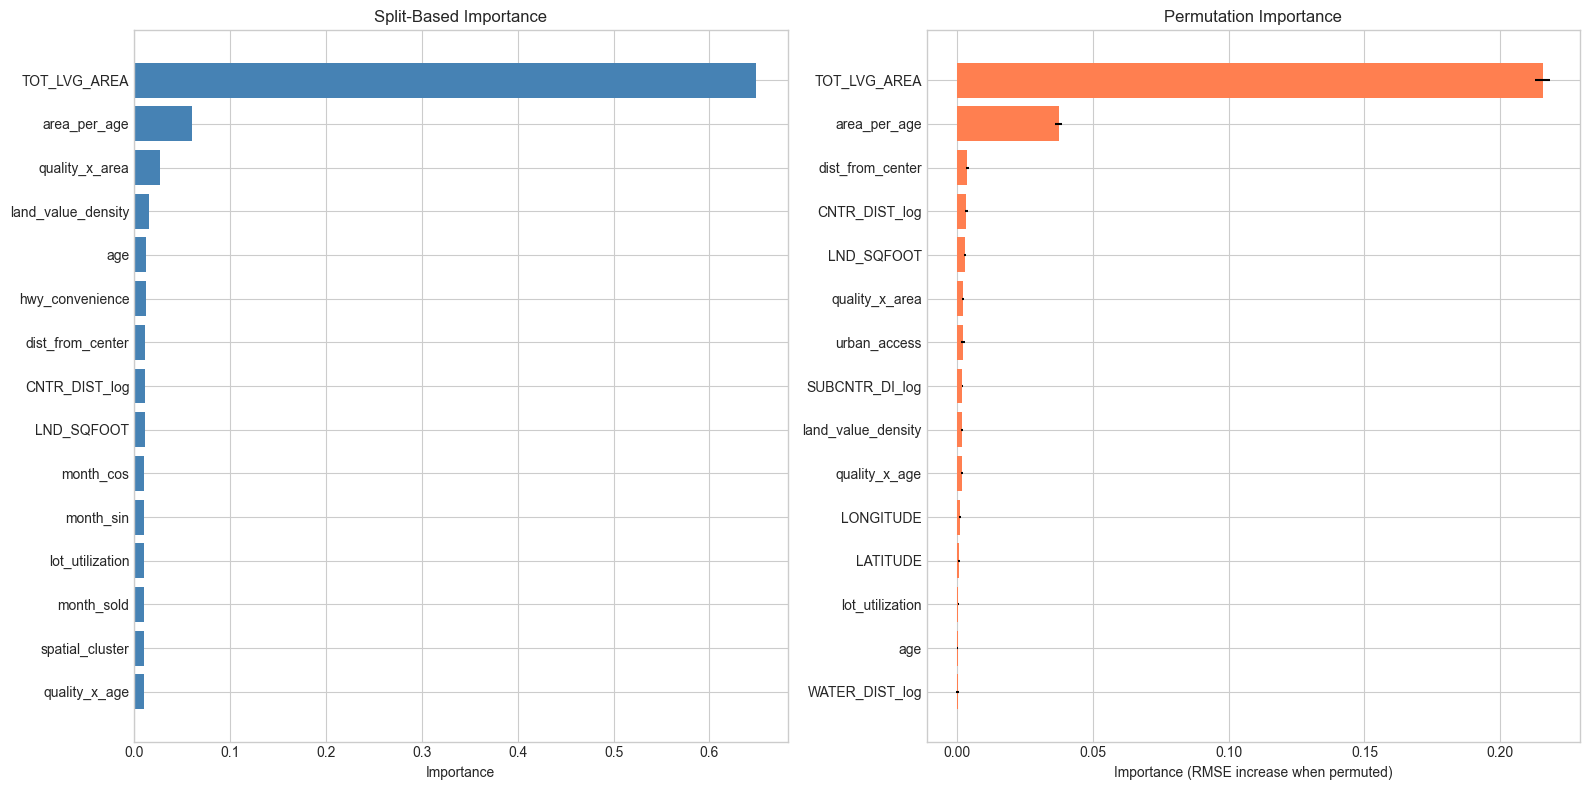

In [34]:
# Compare split-based vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Split-based
top_n = 15
top_split = importance_split.head(top_n)
axes[0].barh(range(top_n), top_split['importance'].values, align='center', color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_split['feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('Split-Based Importance')
axes[0].invert_yaxis()

# Permutation
top_perm = importance_perm.head(top_n)
axes[1].barh(range(top_n), top_perm['importance_mean'].values, align='center', color='coral',
             xerr=top_perm['importance_std'].values)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_perm['feature'].values)
axes[1].set_xlabel('Importance (RMSE increase when permuted)')
axes[1].set_title('Permutation Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [35]:
# ---- SHAP values ----
print("Computing SHAP values (this may take a few minutes)...")
explainer = shap.TreeExplainer(best_model)

# Use a subsample for speed if dataset is large
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

print(f"✓ SHAP values computed for {len(shap_sample)} test samples")

Computing SHAP values (this may take a few minutes)...
✓ SHAP values computed for 1000 test samples


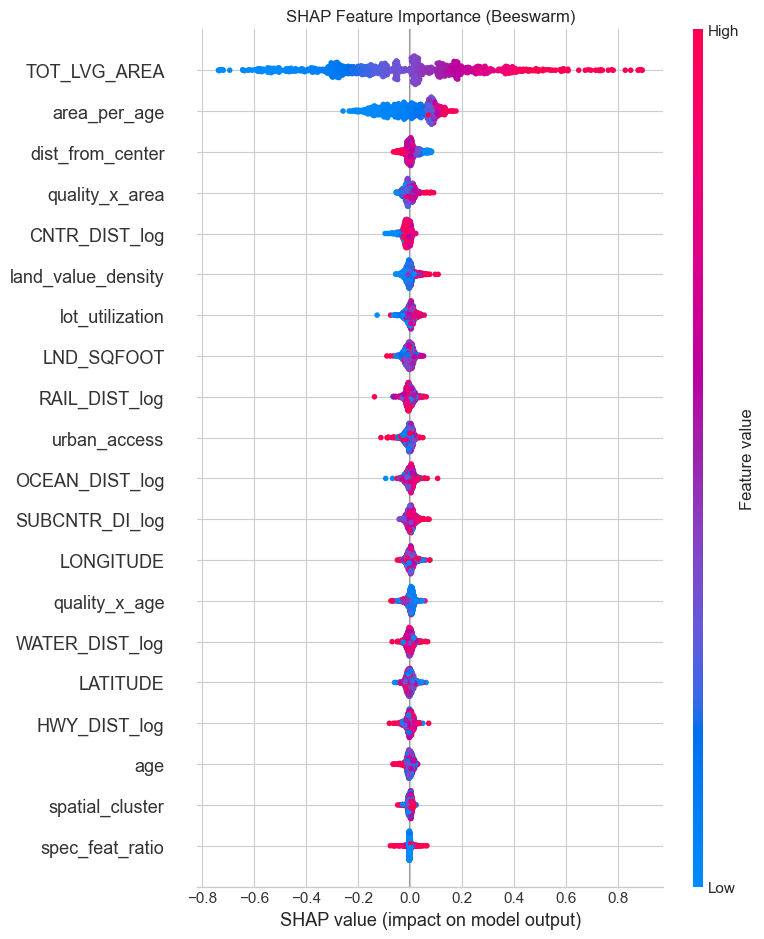

In [36]:
# SHAP summary plot (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=20)
plt.title('SHAP Feature Importance (Beeswarm)')
plt.tight_layout()
plt.show()

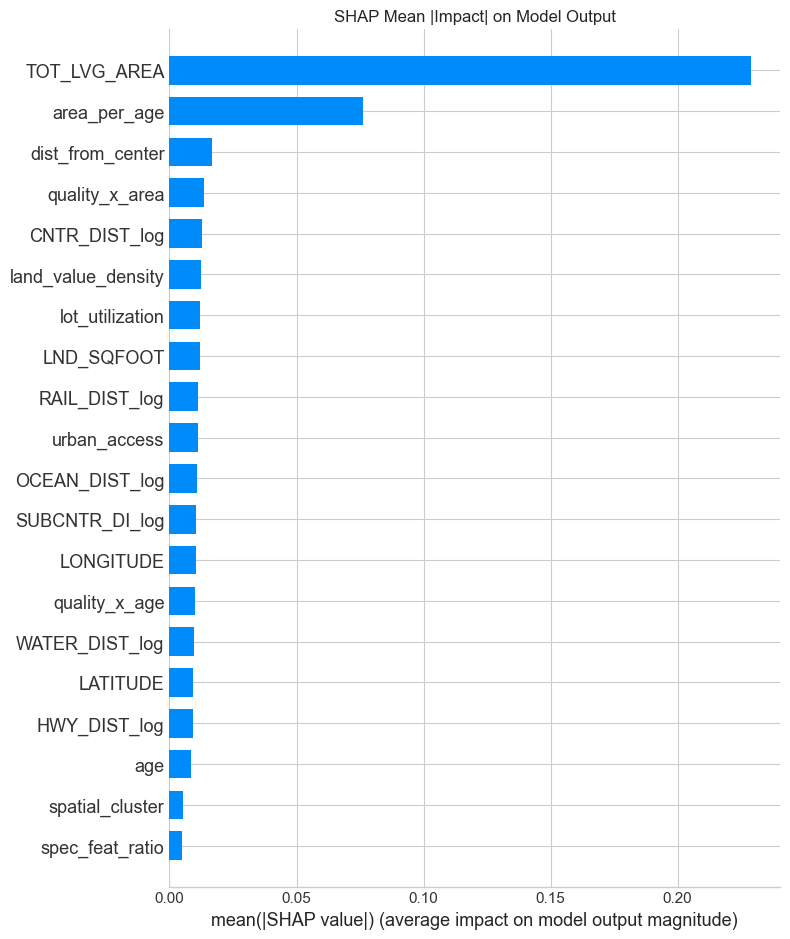

In [37]:
# SHAP bar plot (mean absolute SHAP value)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Mean |Impact| on Model Output')
plt.tight_layout()
plt.show()

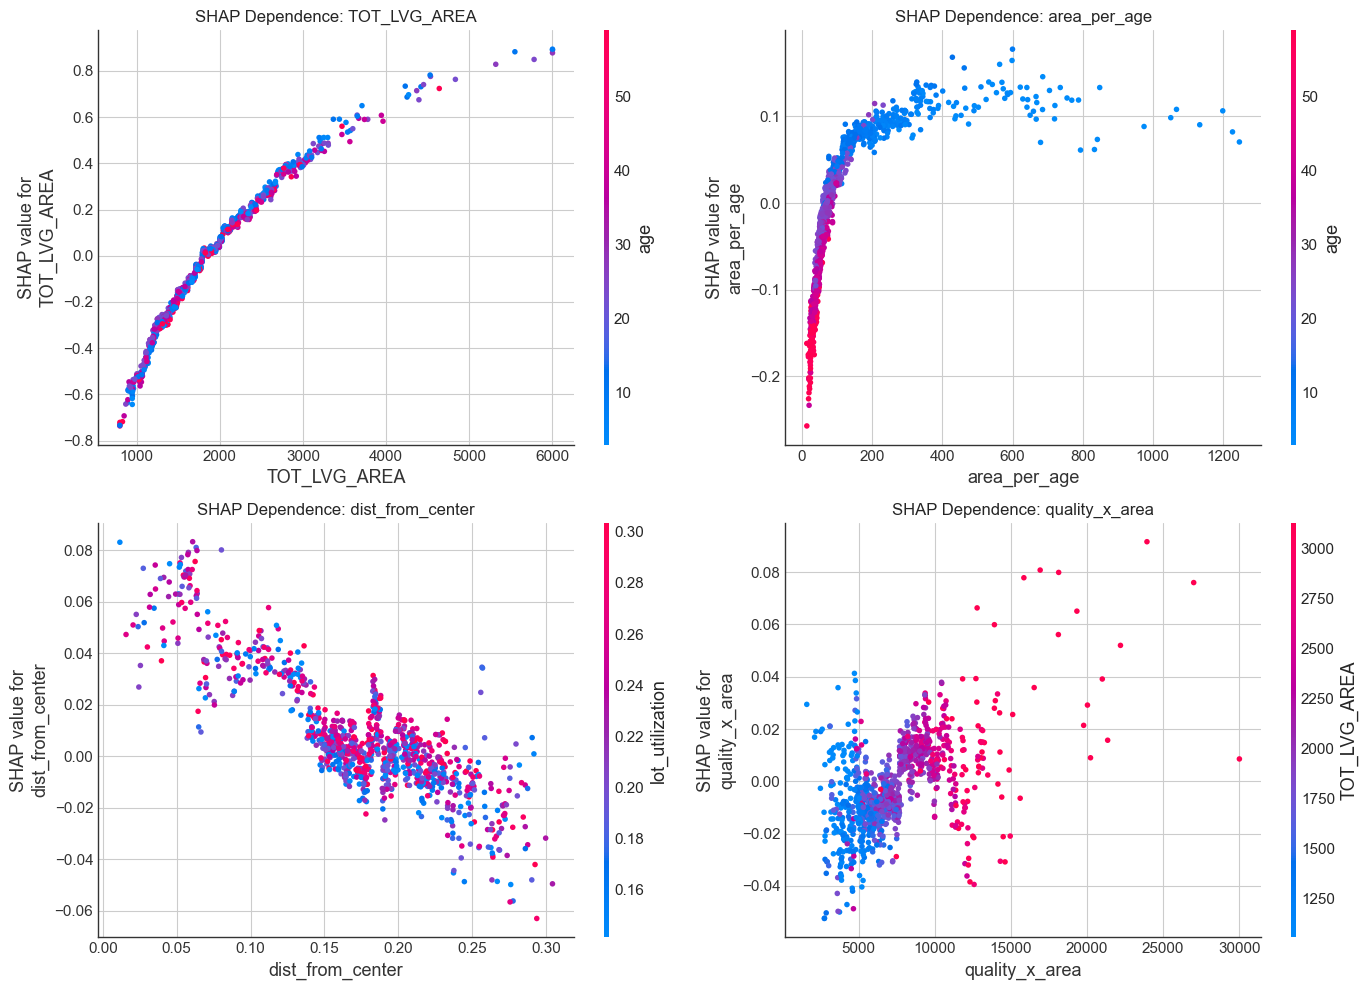

In [38]:
# SHAP dependence plots for top features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_shap_features = pd.DataFrame({
    'feature': X.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)['feature'].head(4).tolist()

for idx, feat in enumerate(top_shap_features):
    ax = axes[idx // 2, idx % 2]
    shap.dependence_plot(feat, shap_values, shap_sample, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.show()

## 11. Residual Diagnostics

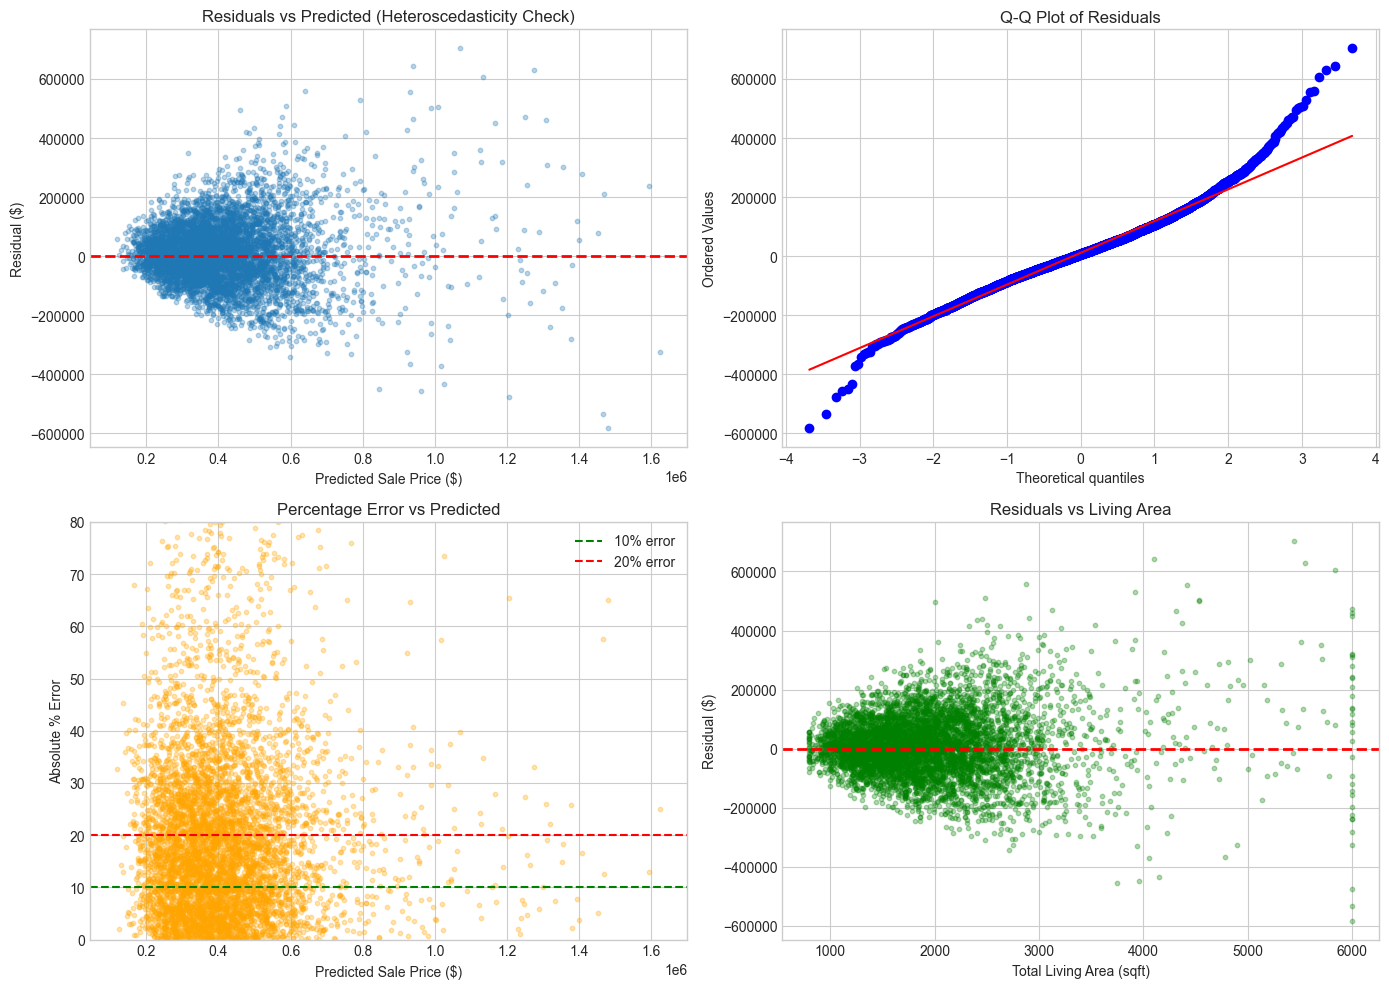

RESIDUAL DIAGNOSTICS
Mean residual:     $11,197
Std residual:      $108,735
Median residual:   $7,232
Skewness:          0.43
Kurtosis:          2.35

→ Model systematically UNDERPREDICTS by ~$11,197 on average.
  This suggests the model misses some positive value drivers.
→ Residuals are approximately symmetric (skew=0.43).


In [39]:
# Residuals analysis
residuals = y_test_orig - y_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_orig, residuals, alpha=0.3, s=10)
axes[0, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Sale Price ($)')
axes[0, 0].set_ylabel('Residual ($)')
axes[0, 0].set_title('Residuals vs Predicted (Heteroscedasticity Check)')

# 2. Residual Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals')

# 3. Percentage errors vs predicted
axes[1, 0].scatter(y_pred_orig, pct_errors, alpha=0.3, s=10, color='orange')
axes[1, 0].axhline(10, color='green', linestyle='--', label='10% error')
axes[1, 0].axhline(20, color='red', linestyle='--', label='20% error')
axes[1, 0].set_xlabel('Predicted Sale Price ($)')
axes[1, 0].set_ylabel('Absolute % Error')
axes[1, 0].set_title('Percentage Error vs Predicted')
axes[1, 0].set_ylim(0, 80)
axes[1, 0].legend()

# 4. Residuals vs key feature (TOT_LVG_AREA)
axes[1, 1].scatter(X_test['TOT_LVG_AREA'], residuals, alpha=0.3, s=10, color='green')
axes[1, 1].axhline(0, color='red', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Total Living Area (sqft)')
axes[1, 1].set_ylabel('Residual ($)')
axes[1, 1].set_title('Residuals vs Living Area')

plt.tight_layout()
plt.show()

# Residual statistics
print("="*60)
print("RESIDUAL DIAGNOSTICS")
print("="*60)
print(f"Mean residual:     ${residuals.mean():,.0f}")
print(f"Std residual:      ${residuals.std():,.0f}")
print(f"Median residual:   ${residuals.median():,.0f}")
print(f"Skewness:          {residuals.skew():.2f}")
print(f"Kurtosis:          {residuals.kurtosis():.2f}")

if residuals.mean() > 0:
    print(f"\n→ Model systematically UNDERPREDICTS by ~${residuals.mean():,.0f} on average.")
    print(f"  This suggests the model misses some positive value drivers.")
else:
    print(f"\n→ Model systematically OVERPREDICTS by ~${abs(residuals.mean()):,.0f} on average.")

if abs(residuals.skew()) > 0.5:
    print(f"→ Residuals are skewed ({residuals.skew():.2f}), indicating non-uniform errors.")
    print(f"  The model handles some price ranges better than others.")
else:
    print(f"→ Residuals are approximately symmetric (skew={residuals.skew():.2f}).")

## 12. Model Limitations & Discussion

### Performance Summary

The tuned XGBoost model achieves meaningful improvement over baselines, but the overall R² indicates significant unexplained variance. This section documents known limitations and potential next steps.

### Known Limitations

1. **Feature coverage:** The dataset contains only physical attributes and distance measures. Key value drivers missing include:
   - School district quality / ratings
   - Crime statistics
   - HOA fees and neighborhood amenities
   - Renovation/remodel history
   - Number of bedrooms/bathrooms (not in this dataset)
   - Market timing / macroeconomic indicators
   - Comparable sales in the neighborhood

2. **Segment weakness:** The model performs worst on properties at the extremes — very low-value and very high-value homes — where within-segment R² may be negative, indicating the model is not much better than predicting the segment mean.

3. **Systematic underprediction:** The positive mean residual indicates the model consistently misses upside, likely due to unobserved quality factors (renovations, views, etc.).

4. **Temporal limitations:** With only `month_sold` (no year), the model cannot capture year-over-year appreciation trends.

### Potential Improvements

- **Enrich features:** Integrate school ratings, crime data, and POI (points of interest) density from external sources
- **Target encoding:** Apply target-encoded spatial clusters for higher-cardinality neighborhood effects
- **Stacking / blending:** Combine XGBoost with LightGBM and/or CatBoost in a meta-learner
- **Quantile regression:** Predict confidence intervals (10th/50th/90th percentile) rather than point estimates
- **Outlier treatment:** Consider Winsorizing or separately modeling the tails

## 13. Save Model & Artifacts

In [40]:
# Save model

best_model.save_model('../output/orlando_fmv_xgboost_model_v2.json')
print(" Model saved: orlando_fmv_xgboost_model_v2.json")

# Save KMeans model (needed for feature engineering at prediction time)
with open('../output/spatial_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print(" KMeans model saved: spatial_kmeans.pkl")

# Save feature importance (all 3 types)
importance_split.to_csv('../output/feature_importance_split.csv', index=False)
importance_perm.to_csv('../output/feature_importance_permutation.csv', index=False)
print(" Feature importance saved")

# Save CV results
cv_results.to_csv('../output/cv_results_v2.csv', index=False)
print(" CV results saved: cv_results_v2.csv")

# Save feature list
feature_list = X.columns.tolist()
pd.Series(feature_list).to_csv('../output/feature_list_v2.csv', index=False, header=False)
print(" Feature list saved: feature_list_v2.csv")

# Save segment analysis
seg_df.to_csv('../output/segment_analysis_v2.csv', index=False)
print(" Segment analysis saved: segment_analysis_v2.csv")

 Model saved: orlando_fmv_xgboost_model_v2.json
 KMeans model saved: spatial_kmeans.pkl
 Feature importance saved
 CV results saved: cv_results_v2.csv
 Feature list saved: feature_list_v2.csv
 Segment analysis saved: segment_analysis_v2.csv


## 14. Prediction Function for New Properties

In [41]:
def predict_fair_market_value(model, feature_names, property_data, kmeans_model=None):
    """
    Predict FMV for a new property.
    
    Parameters:
    -----------
    model : trained XGBoost model
    feature_names : list of feature names in correct order
    property_data : dict with property attributes
    kmeans_model : fitted KMeans for spatial clusters
    
    Returns:
    --------
    float : Predicted fair market value in USD
    """
    df = pd.DataFrame([property_data])
    df = engineer_features(df, kmeans_model=kmeans_model)
    df = df[feature_names]
    
    pred_log = model.predict(df)[0]
    pred_value = np.expm1(pred_log)
    
    return pred_value

In [42]:
# Example prediction
example_property = {
    'LATITUDE': 28.55,
    'LONGITUDE': -81.35,
    'LND_SQFOOT': 8500,
    'TOT_LVG_AREA': 2000,
    'SPEC_FEAT_VAL': 10000,
    'RAIL_DIST': 5000,
    'OCEAN_DIST': 55000,
    'WATER_DIST': 1500,
    'CNTR_DIST': 40000,
    'SUBCNTR_DI': 8000,
    'HWY_DIST': 3000,
    'age': 15,
    'avno60plus': 0,
    'month_sold': 6,
    'structure_quality': 4.0
}

predicted_fmv = predict_fair_market_value(best_model, feature_list, example_property, kmeans_model=kmeans)

print("="*60)
print("EXAMPLE PREDICTION")
print("="*60)
print("\nProperty Attributes:")
for key, value in example_property.items():
    print(f"  {key}: {value}")
print(f"\n>>> Predicted Fair Market Value: ${predicted_fmv:,.0f}")

EXAMPLE PREDICTION

Property Attributes:
  LATITUDE: 28.55
  LONGITUDE: -81.35
  LND_SQFOOT: 8500
  TOT_LVG_AREA: 2000
  SPEC_FEAT_VAL: 10000
  RAIL_DIST: 5000
  OCEAN_DIST: 55000
  WATER_DIST: 1500
  CNTR_DIST: 40000
  SUBCNTR_DI: 8000
  HWY_DIST: 3000
  age: 15
  avno60plus: 0
  month_sold: 6
  structure_quality: 4.0

>>> Predicted Fair Market Value: $474,295


In [43]:
def load_model_and_predict(model_path, feature_list_path, kmeans_path, property_data):
    """
    Load saved model and make predictions.
    
    Usage:
    ------
    predicted_value = load_model_and_predict(
        'orlando_fmv_xgboost_model_v2.json',
        'feature_list_v2.csv',
        'spatial_kmeans.pkl',
        property_dict
    )
    """
    # Load model
    loaded_model = xgb.XGBRegressor()
    loaded_model.load_model(model_path)
    
    # Load feature list
    feature_names = pd.read_csv(feature_list_path, header=None)[0].tolist()
    
    # Load KMeans
    with open(kmeans_path, 'rb') as f:
        kmeans_model = pickle.load(f)
    
    return predict_fair_market_value(loaded_model, feature_names, property_data, kmeans_model=kmeans_model)

print("✓ load_model_and_predict() defined for production use")

✓ load_model_and_predict() defined for production use


---

## Summary

| Metric | v1 | v2 |
|--------|-----|-----|
| **Features (Engineered)** | 28 | ~28 (refined: removed redundant, added interactions) |
| **Tuning Method** | GridSearchCV (972 combos) | Optuna (100 Bayesian trials + early stopping) |
| **Early Stopping** | No | Yes |
| **Baselines Compared** | None | Median, Linear Regression, Default XGBoost |
| **Interpretability** | Split importance only | Split + Permutation + SHAP |
| **Error Analysis** | Global only | Global + Segment + Worst-case deep dive |
| **Residual Analysis** | Plotted, not discussed | Full diagnostics with interpretation |
| **Limitations** | Not documented | Documented with next steps |

### Files Saved:
- `orlando_fmv_xgboost_model_v2.json` — Trained model
- `spatial_kmeans.pkl` — KMeans model for spatial clusters
- `feature_importance_split.csv` — Split-based feature rankings
- `feature_importance_permutation.csv` — Permutation-based feature rankings
- `cv_results_v2.csv` — Cross-validation metrics per fold
- `feature_list_v2.csv` — Feature names for prediction
- `segment_analysis_v2.csv` — Performance by price segment